In [257]:
import warnings
import pandas as pd
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore', message='KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.')
from tensorflow.keras.layers import Input, Dense
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, accuracy_score, f1_score, confusion_matrix, silhouette_score
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers
from sklearn import datasets
import random
from sklearn.cluster import KMeans

You are provided with a dataset of different aircraft that includes three
columns: Aircraft (string; not used in clustering), Speed_kmh (cruise speed in km/h),
and FuelFlow_kgph (cruise fuel flow in kg/hour for the whole aircraft). Using only the
numeric features Speed_kmh and FuelFlow_kgph, apply k-means clustering to group the
aircraft into meaningful performance categories. Be sure to standardize the features (for
example, with StandardScaler) before clustering. For values of k from 2 to 6, compute
the silhouette score and plot the score as a function of k. Based on your plot, select a
reasonable value of k, fit k-means, and create a scatter plot of cruise speed versus fuel
flow where points are colored according to their assigned cluster. Finally, briefly interpret
each cluster in engineering terms,for example, “fast and high fuel flow corresponds to
jets,” while “slower and very low fuel flow corresponds to general aviation aircraft.” As
an optional step, you may label a few representative aircraft on your plot to make the
clusters more interpretable.

                  Aircraft  Speed_kmh  FuelFlow_kgph
0               Cessna_172        226             24
1               Cessna_182        260             30
2               Piper_PA28        215             22
3             Diamond_DA40        240             26
4              Cirrus_SR20        250             29
5              Cirrus_SR22        300             36
6            Beech_Bonanza        285             34
7               Mooney_M20        290             33
8             Pilatus_PC12        520            780
9   Beechcraft_KingAir_200        540            900
10                  ATR_72        510            950
11              Dash8_Q400        610           1100
12            Embraer_E175        820           1600
13            Embraer_E190        830           1800
14                  CRJ700        780           1500
15                  CRJ900        800           1650
16             Airbus_A320        840           2600
17          Boeing_737_800        845         

Text(0.5, 1.0, 'Fuel Flow vs Cruising Speed')

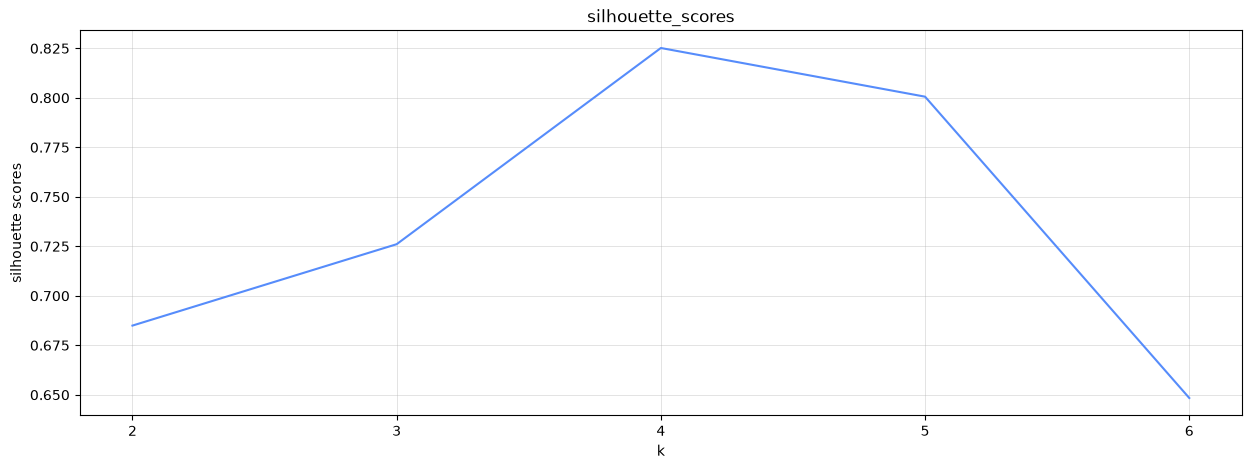

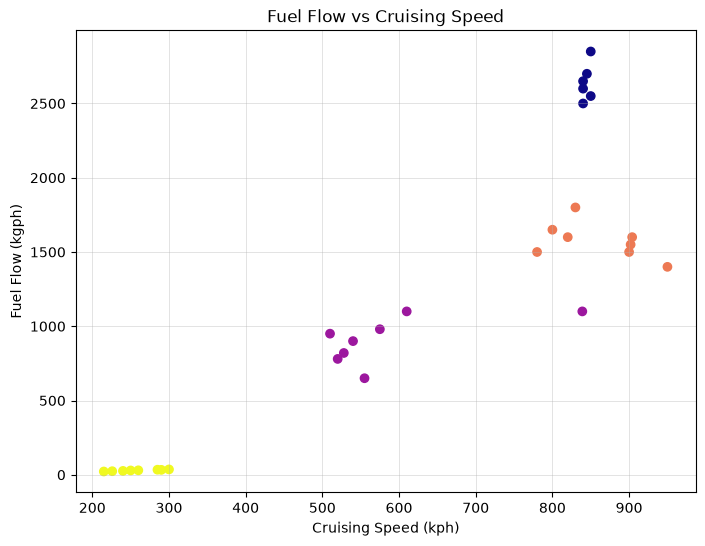

In [247]:
numclusters = 4
### Prepare the data
df = pd.read_csv('aircraft_performance.csv')
X = df.drop('Aircraft', axis=1).to_numpy()  # feature vector
print(df)
# y will not be used because we are doing unsupervised learning
### ideally we should only split X because the data is supposed to be not labeled
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    X,
    test_size=0.30,
    train_size=0.70,
    random_state=123,
    shuffle=True)
XtrainScaled = StandardScaler().fit_transform(X_train)




silhouette_scores = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, init='k-means++',
                    n_init='auto', )
    kmeans.fit(XtrainScaled)
    silhouette_scores.append(silhouette_score(XtrainScaled, kmeans.labels_))

fig = plt.figure(figsize=(15, 5))
plt.plot(range(2, 7), silhouette_scores)
plt.grid(True)
plt.xticks(ticks=range(2, 7))
plt.title('silhouette_scores')
plt.xlabel('k')
plt.ylabel('silhouette scores')

skmodel = KMeans(
    n_clusters=numclusters,
    init='k-means++',
    n_init='auto',
    max_iter=300,
    tol=0.0001,
    verbose=0,
    random_state=None,
    copy_x=True,
    algorithm='lloyd',
)

skmodel.fit(X_train)
skmodel.labels_  # training labels
skmodel.predict(X_test)  # predict labels, remember the integers do not make same sense in training and testing for clustering
skmodel_labels = skmodel.predict(X)
#df['skmodel_labels'] = skmodel_labels
fig = plt.figure(figsize=(8, 6))

#ax = fig.add_subplot(projection='3d')
plt.scatter(X[:, 0], X[:, 1], c=skmodel_labels.tolist(), cmap='plasma')
plt.grid(True)
plt.ylabel('Fuel Flow (kgph)')
plt.xlabel('Cruising Speed (kph)')
plt.title('Fuel Flow vs Cruising Speed')
#plt.view_init(elev=20, azim=50)

Implement your own linear machine learning model optimized with mini-batch
gradient descent method to predict the price of a house in a city with population of 160,
000. Train the model to fit the housing prices dataset found on LMS. Vary the batch size
from 1,5,10, and 20. Plot the objective function, J for each batch size. You do not need to
split the data into train and test set for this problem. What happens when you use batch
size equal to one?

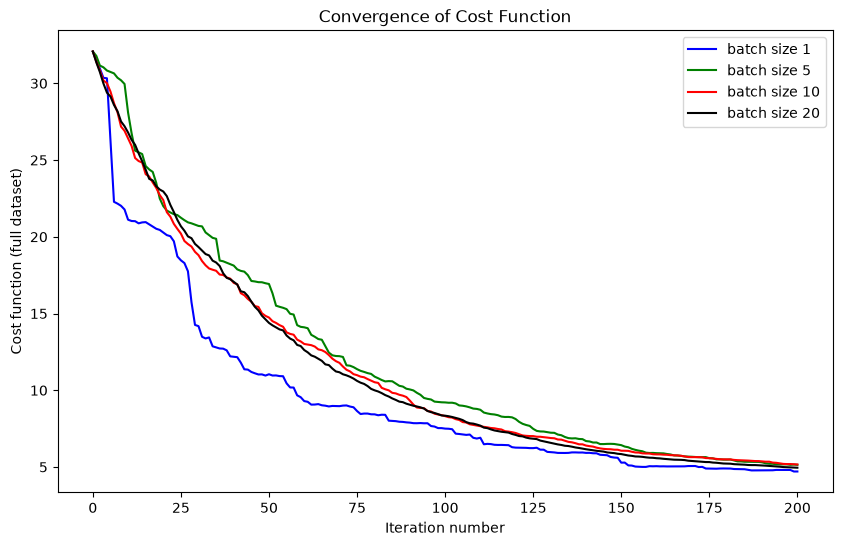

[151754.72625055]


In [248]:
Batches = np.array([1, 5, 10, 20])
datafile = 'housing_prices.txt'
cols = np.loadtxt(datafile,delimiter=',',usecols=(0,1),unpack=True)
X = np.transpose(np.array(cols[:-1]))
y = np.transpose(np.array(cols[-1:]))
m = y.size

scaler = StandardScaler()
XtrainScaled = scaler.fit_transform(X[:, 0:1])        # feature column only
XtrainScaled = np.insert(XtrainScaled, 0, 1, axis=1)  # Add bias after scaling

def h(w, X):
    return np.dot(X, w)

def mse(w, X, y):
    m = len(y)
    err = h(w, X) - y
    return ((err.T @ err) / (2 * m)).item()

def gradient_descend(X, y, batchsize=5, iterations=200, alpha=0.01):
    n = len(X)
    w = np.zeros((X.shape[1], 1))
    J_values = [mse(w, X, y)]
    w_store = [w[:, 0].copy()]

    for _ in range(iterations):
        # pick one random mini-batch (without replacement within the batch)
        idx = np.random.choice(n, size=min(batchsize, n), replace=False)
        Xb, yb = X[idx], y[idx]

        # vectorized gradient, simultaneous update of all weights
        grad = (Xb.T @ (h(w, Xb) - yb)) / len(yb)
        w = w - alpha * grad

        J_values.append(mse(w, X, y))
        w_store.append(w[:, 0].copy())
    return w, w_store, J_values

colors = ['b-', 'g-', 'r-', 'k-']
plt.figure(figsize=(10, 6))
for a, bs in enumerate(Batches):
    w, w_store, J_values = gradient_descend(XtrainScaled, y, batchsize=bs)
    plt.plot(J_values, colors[a], label=f'batch size {bs}')

plt.title("Convergence of Cost Function")
plt.xlabel("Iteration number")
plt.ylabel("Cost function (full dataset)")
plt.legend()
plt.show()

# Reset for the prediction using batches of size 20
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X[:, 0:1])
Xs = np.insert(x_scaled, 0, 1, axis=1)

w, w_store, J_values = gradient_descend(Xs, y, batchsize=20, iterations=1000)

def predict(xval):
    xs = scaler.transform(np.array([[xval]]))[0, 0]
    return w[0] + w[1]*xs

print(predict(16)*10000)

Use the Scikit-learn breast cancer Wisconsin dataset and a logistic regression
model to classify breast cancers. You must recursively eliminate features to find the best
two features to perform the classification. Evaluate the model using various classification
metrics and report your findings. Use a 70%-30% split.


True/False Selection of features: [False False False False False False False False False False False False
 False False False False False False False False False False False  True
 False False False  True False False]
The best features are :  ['worst area' 'worst concave points']
Using the two best features, the classification metrics are as follows:
 Accuracy = 0.9941520467836257 
 Recall =  1.0 
 f1 =  0.9951690821256038


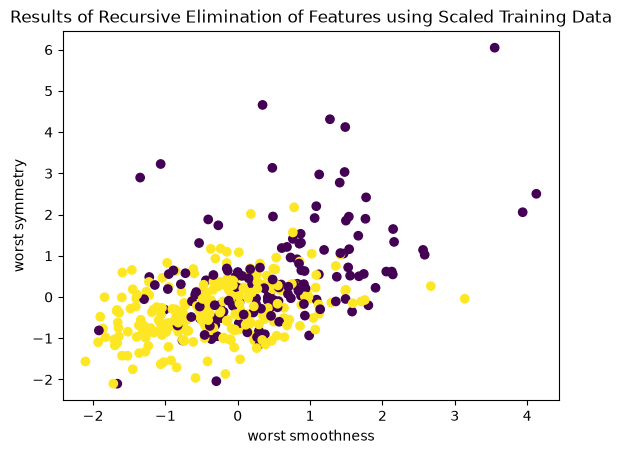

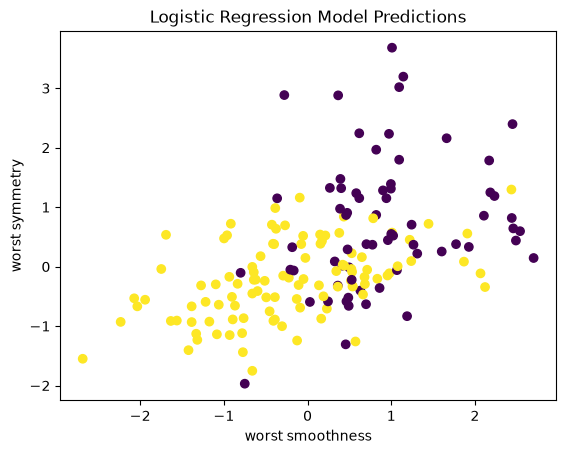

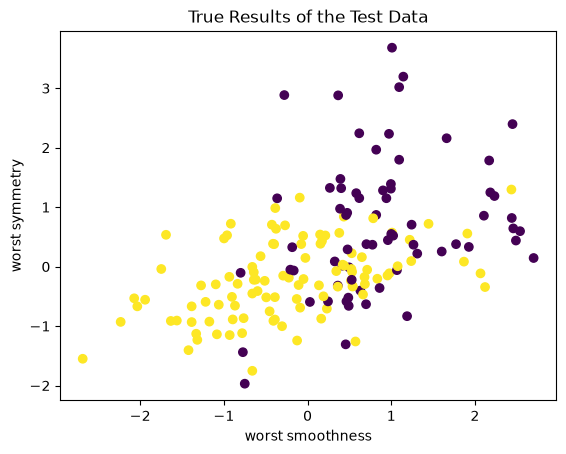

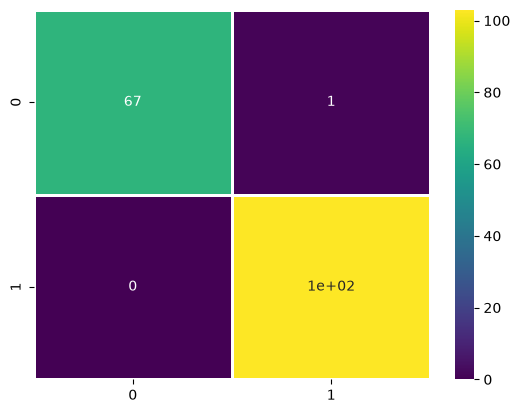

In [249]:
### Prepare the data
bc = load_breast_cancer()
X = bc.data[:, :]  # Selecting all features
y = bc.target
target_names = bc.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    train_size=0.70,
    random_state=123,
    shuffle=True)
scaler=StandardScaler()
XtrainScaled = scaler.fit_transform(X_train)
XtestScaled = scaler.transform(X_test)

model=LogisticRegression(max_iter=5000)
model.fit(XtrainScaled, y_train)

rfe = RFE(model, n_features_to_select=2)
rfe = rfe.fit(XtrainScaled, y_train)
print('True/False Selection of features:', rfe.support_)
feature_indices = np.linspace(1,30,num=30)
feature_indices = feature_indices[rfe.support_]

plt.figure()
plt.scatter(XtrainScaled[:,int(feature_indices[0])], XtrainScaled[:,int(feature_indices[1])], c =y_train)
plt.xlabel(bc.feature_names[int(feature_indices[0])])
plt.ylabel(bc.feature_names[int(feature_indices[1])])
plt.title('Results of Recursive Elimination of Features using Scaled Training Data')
print('The best features are : ', np.array(bc.feature_names)[rfe.support_])

plt.figure()
predictions = model.predict(XtestScaled)
plt.scatter(XtestScaled[:,int(feature_indices[0])], XtestScaled[:,int(feature_indices[1])], c =predictions)
plt.xlabel(bc.feature_names[int(feature_indices[0])])
plt.ylabel(bc.feature_names[int(feature_indices[1])])
plt.title('Logistic Regression Model Predictions')

plt.figure()
predictions = model.predict(XtestScaled)
plt.scatter(XtestScaled[:,int(feature_indices[0])], XtestScaled[:,int(feature_indices[1])], c =y_test)
plt.xlabel(bc.feature_names[int(feature_indices[0])])
plt.ylabel(bc.feature_names[int(feature_indices[1])])
plt.title('True Results of the Test Data')

recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
accuracy = accuracy_score(y_test, predictions)

print('Using the two best features, the classification metrics are as follows:'
'\n Accuracy =', accuracy,
'\n Recall = ', recall,
'\n f1 = ', f1)

plt.figure()
cm_sk = confusion_matrix(y_test, predictions)
ax = sns.heatmap(cm_sk,linewidths=2, annot=True, cmap='viridis', cbar=True);

Construct a neural network with a single hidden layer containing two neurons
using Tensorflow. Use ReLU as activation function. Optimize the network with stochastic
gradient descent method. Choose mean squared error to calculate the loss. Fit the
housing prices dataset found on LMS using the network. Use the trained neural network
model to predict the price of a house in a city with population of 165, 000. Calculate a
useful regression metric. Plot the training and validation losses. Use a 70%-30% split
for the training and validation dataset. The architecture of the neural network and the
optimizer are fixed for this problem. Therefore, you need to choose a suitable learning
rate and number of epochs to minimize the loss. Explain the trends you found in the
plots for training and validation losses.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
The expected price of a house in a city with a population of 165,000 is approximately  161580.2001953125  dollars


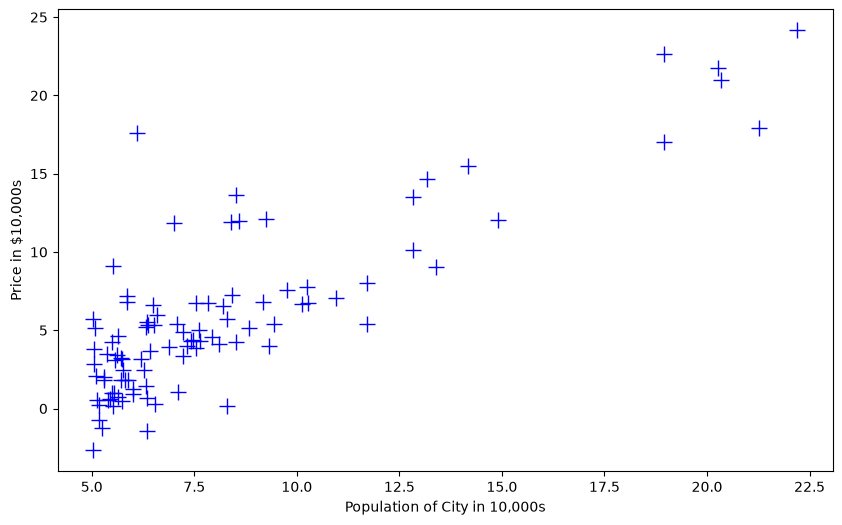

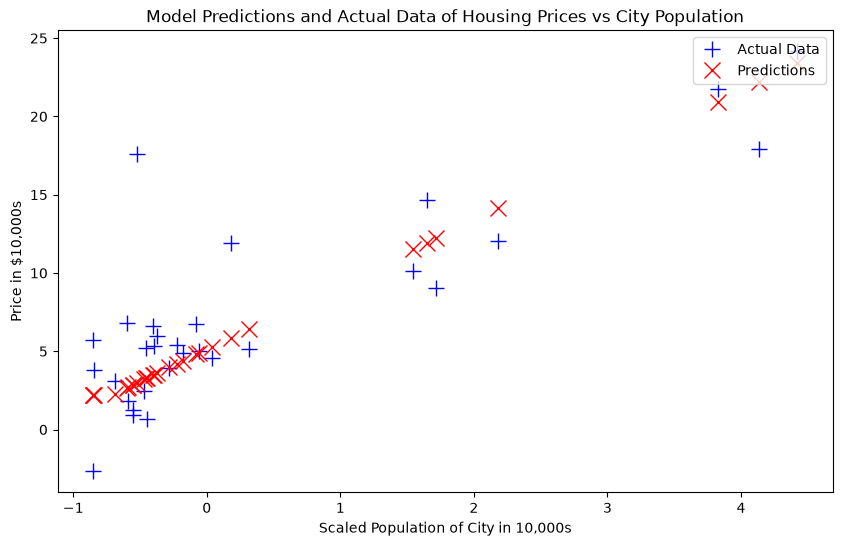

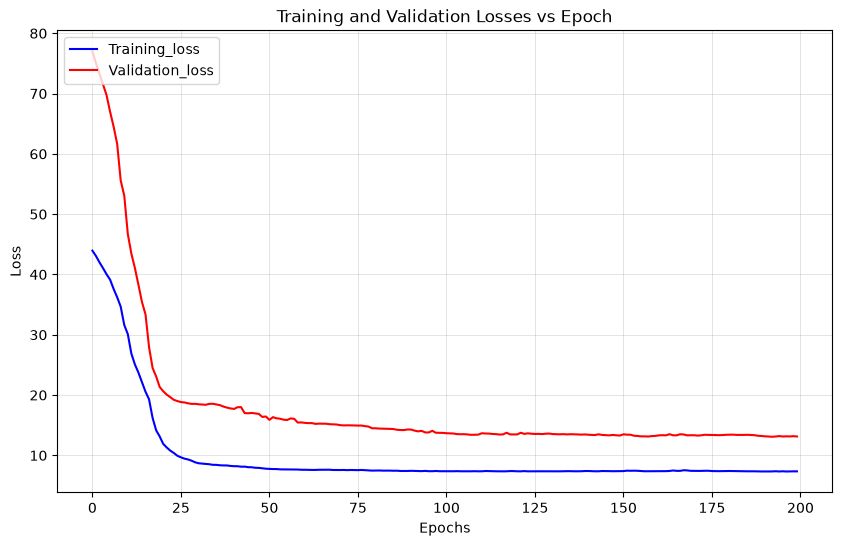

In [265]:
#Load dataset
datafile = 'housing_prices.txt'
cols = np.loadtxt(datafile,delimiter=',',usecols=(0,1),unpack=True)
X = np.transpose(np.array(cols[:-1]))
y = np.transpose(np.array(cols[-1:]))
m = y.size
X = np.insert(X,0,1,axis=1)

plt.figure(figsize=(10,6))
plt.plot(X[:,1],y[:,0],'b+',markersize=12)
plt.xlabel('Population of City in 10,000s')
plt.ylabel('Price in $10,000s')

X_train, X_test, y_train, y_test=train_test_split(
    X[:,1],y,
    test_size=0.30,
    train_size=0.70,
    random_state=123,
    shuffle=True)

X_train = X_train.reshape(-1,1)
X_test = X_test.reshape(-1,1)

scaler=StandardScaler()
XtrainScaled = scaler.fit_transform(X_train)
XtestScaled = scaler.transform(X_test)

#define keras model
model = Sequential([Input(shape=(1,)), Dense(1,activation='relu'), Dense(2,activation='relu'), Dense(1)])

#compile the keras model
opt = optimizers.SGD(learning_rate=0.001)
model.compile(loss='mse', optimizer=opt)

numepochs = 200
#fit the keras model on the dataset (CPU)
trainedmodel = model.fit(XtrainScaled,y_train, epochs=numepochs, verbose=0, validation_data=(XtestScaled, y_test))
train_loss = trainedmodel.history['loss']
test_loss = trainedmodel.history['val_loss']

#make class predictions with the model
predictions = model.predict(XtestScaled)

plt.figure(figsize=(10,6))
plt.plot(XtestScaled, y_test, 'b+', markersize=12, label='Actual Data')
plt.plot(XtestScaled, predictions, 'rx', markersize=12, label='Predictions')
plt.xlabel('Scaled Population of City in 10,000s')
plt.ylabel('Price in $10,000s')
plt.legend(loc='upper right')
plt.title('Model Predictions and Actual Data of Housing Prices vs City Population')

plt.figure(figsize=(10,6))
plt.plot(range(0,numepochs), train_loss, 'b-', label='Training_loss')
plt.plot(range(0,numepochs), test_loss, 'r-', label='Validation_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses vs Epoch')
plt.legend(loc='upper left')
plt.grid(True)

print('The expected price of a house in a city with a population of 165,000 is approximately ', model.predict(scaler.transform(np.array([[16.5]]))).item() * 10000, ' dollars')
